In [2]:
#from a fieldmap in straight coordinates to one in curved coordinates
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
from sympy import lambdify 
from sympy.abc import x, y, s
from scipy.integrate import cumulative_trapezoid as cumtrapz 

(0.0, 1.0)

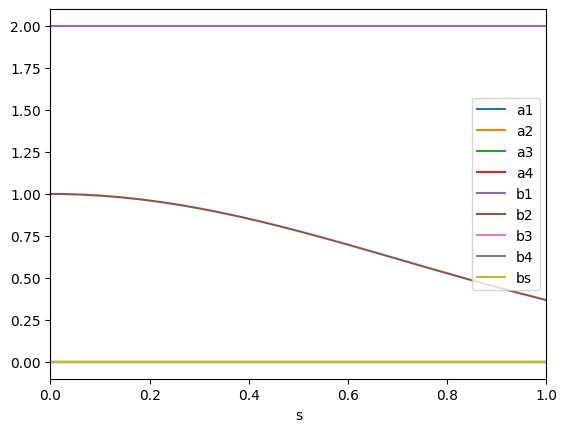

In [3]:
#start from multipole coeefficients a_n(s)=a1,a2,... and b_n(s)
a_coeffs = [0, 0, 0, 0]
b_coeffs = [2,"exp(-s**2)",0, 0]
#get scalar potential
expansion=bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs)
expansion.plot_components()
plt.xlabel('s')
plt.xlim((0,1))

In [4]:
#XYS=(x,y,s)#symbolic expressions
#define x,y,s axes to convert the symbolic expression of phi into a numerical array
xa= np.linspace(-1,1,101)
ya=np.linspace(-1,1,101)
sa=np.linspace(-1,1,101)
#make a 3d plot of phi as a function of x and y for a fixed s
X, Y = np.meshgrid(xa, ya)
# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)
#print("Bx:", Bx_func, "By:", By_func, "Bs:", Bs_func)
# Evaluate on grid
X,Y,S = np.meshgrid(xa, ya, sa)
Bx_num = Bx_func(X, Y, S)
By_num = By_func(X, Y, S)
Bs_num = Bs_func(X, Y, S)
#print("Bx shape:", Bx_ana.shape, "By shape:", By_ana.shape, "Bs shape:", Bs_ana.shape)
# X, Y, S  from meshgrid in straight frame
# Bx_ana, By_ana, Bs_ana are the corresponding field arrays
datafieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    Bx_num.ravel(),
    By_num.ravel(),
    Bs_num.ravel()
])
#print("Data shape (N, 6):", datafieldmap.shape)
fm = bpmeth.fieldmaps.Fieldmap(datafieldmap)

In [5]:
rho = .5
phi = 1.
N=101 #don't touch for the moment
xFS = np.linspace(-0.05, 0.05, N)
yFS = np.linspace(-0.05, 0.05, N)
sFS = np.linspace(-rho*phi, rho*phi, 103)
interp_rad=0.025
fm_fs = fm.calc_FS_coords(xFS, yFS, sFS, rho, phi, radius=interp_rad)

$\vec{A}$ can be recovered from\
$
\begin{align}
    A_x(x, y, s) &= -\int_0^y B_s(x, \tilde{y}, s)  \; d\tilde{y} \\
    A_y(x, y, s) &= 0 \\
    A_s(x, y, s) &= \int_0^y B_x(x, \tilde{y}, s) \; d\tilde{y} - \frac{1}{1+hx} \int_0^x (1+h\tilde{x}) B_y(\tilde{x}, 0, s) \; d\tilde{x}
\end{align}$

In [6]:
Nhalf = np.floor(N/2).astype(int)
Acurvedx= -cumtrapz(Bs_num[Nhalf:,Nhalf:,Nhalf:], yFS[Nhalf:],axis=1, initial=0)
Acurvedy= np.zeros_like(Acurvedx)
Acurveds= cumtrapz(Bx_num[Nhalf:,Nhalf:,Nhalf:], yFS[Nhalf:],axis=1, initial=0)-1/(1+xFS[Nhalf:]/rho)*cumtrapz(By_num[Nhalf:,Nhalf:,Nhalf:], xFS[Nhalf:],axis=0, initial=0)
#take just an octant for A for broadcasting reasons

And then back to the $\vec{B}$ field:\
$ \begin{align}
    \mathbf{B} &= \nabla\times\mathbf{A}  =
    \left(\partial_y A_s - \frac{\partial_s  A_y}{1+h x} \right) \mathbf{\hat{x}} 
    +\left(\frac{\partial_s A_x-\partial_x (1+h x) A_s }{1+h x} \right)\mathbf{\hat{y}} \nonumber 
    & +\left(\partial_x A_y - \partial_y A_x \right) \mathbf{\hat{s}} \,.
\end{align} $

In [7]:
def curl_curved(Ax, Ay, As, dx, dy, ds, h):
  
    # Compute partial derivatives
    dAx_dy = np.gradient(Ax, dy, axis=1)
    dAx_ds = np.gradient(Ax, ds, axis=2)
    dAy_dx = np.gradient(Ay, dx, axis=0)
    dAy_ds = np.gradient(Ay, ds, axis=2)
    d1plushxAs_dx = np.gradient((1+h*xFS[Nhalf:])*As, dx, axis=0)
    dAs_dy = np.gradient(As, dy, axis=1)
    
    # Curl components
    curl_x = dAs_dy - dAy_ds/(1 + xFS[Nhalf:]*h)
    curl_y = (dAx_ds - d1plushxAs_dx)/(1 + xFS[Nhalf:]*h)
    curl_s = dAy_dx - dAx_dy
    
    return curl_x, curl_y, curl_s
curlAx, curlAy, curlAs = curl_curved(Acurvedx, Acurvedy, Acurveds, xFS[1]-xFS[0], yFS[1]-yFS[0], sFS[1]-sFS[0], 1/rho)
# Compare with computed curl
print("Max difference in Bx:", np.max(np.abs(curlAx - Bx_num[Nhalf:,Nhalf:,Nhalf:])))
print("Max difference in By:", np.max(np.abs(curlAy - By_num[Nhalf:,Nhalf:,Nhalf:])))
print("Max difference in Bs:", np.max(np.abs(curlAs - Bs_num[Nhalf:,Nhalf:,Nhalf:])))

Max difference in Bx: 1.333400000000055
Max difference in By: 1.809458809606617
Max difference in Bs: 0.01473492400662019


In [9]:
datafieldmap = np.column_stack([
    X[Nhalf:, Nhalf:, Nhalf:].ravel(),
    Y[Nhalf:, Nhalf:, Nhalf:].ravel(),
    S[Nhalf:, Nhalf:, Nhalf:].ravel(),
    curlAx.ravel(),
    curlAy.ravel(),
    curlAs.ravel()
])
#print("Data shape (N, 6):", datafieldmap.shape)
fm_curved = bpmeth.fieldmaps.Fieldmap(datafieldmap)

In [10]:
# Choose a fixed s value (s=0 is the magnet center)
s_fixed = 0.0

bnianHA=fm_curved.harmonic_analysis_at_s(spos=s_fixed,rmin=0.01,rmax=1.0 )
print("recovered bn(0) in curved frame: ", bnianHA.real)


recovered bn(0) in curved frame:  [ 1.29801547e+00 -6.42515488e+00 -2.69924344e+03  6.67577638e+05
  3.31485196e+08]
